In [1]:
import pandas as pd
from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import plot_tree

%matplotlib inline


In [2]:
data = pd.read_excel('Calidad_del_agua_data.xlsx')

In [3]:
data.head()

,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence,Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Oxygenation Interventions,Corrective Interventions,High Temperature (°C),Low Temperature (°C),Oxygenation Automatic,Thermal Risk Index,Low Oxygen Alert,Health Status
0,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable
1,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
2,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1,0,33.9,24.1,Yes,Normal,Safe,Stable
3,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
4,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable


In [4]:
report = data.profile_report(html={'style':{'full_width':True}})
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

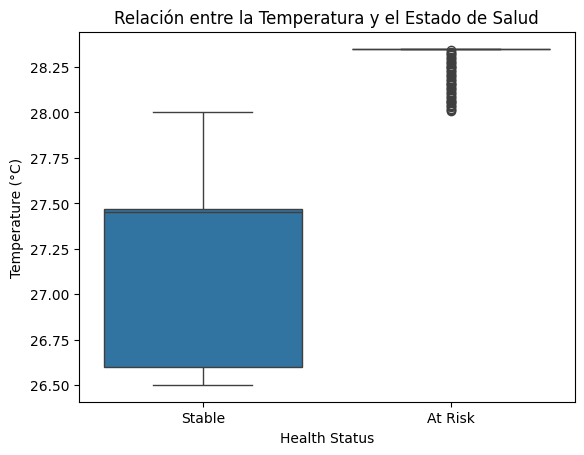

In [5]:
sns.boxplot(x='Health Status', y='Temperature (°C)', data=data)
plt.title('Relación entre la Temperatura y el Estado de Salud')
plt.show()

In [6]:
data.head()

,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence,Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Oxygenation Interventions,Corrective Interventions,High Temperature (°C),Low Temperature (°C),Oxygenation Automatic,Thermal Risk Index,Low Oxygen Alert,Health Status
0,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable
1,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
2,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1,0,33.9,24.1,Yes,Normal,Safe,Stable
3,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
4,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable


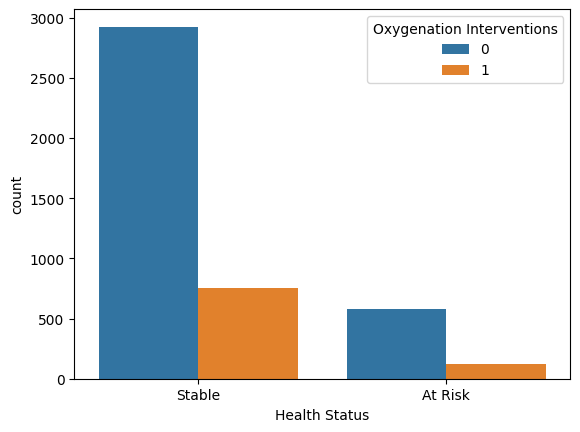

In [7]:
sns.countplot(x='Health Status', hue='Oxygenation Interventions', data=data)
plt.show()

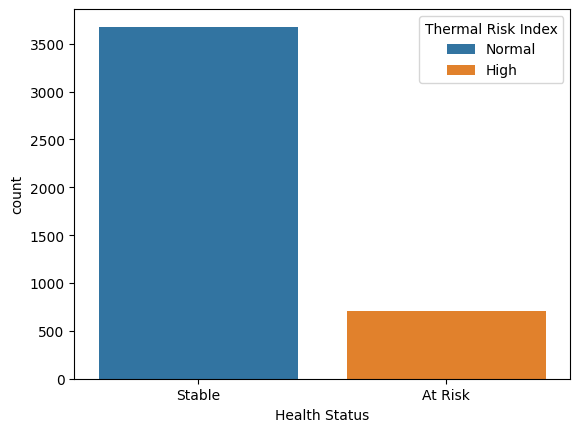

In [8]:
sns.countplot(x='Health Status', hue='Thermal Risk Index', data=data)
plt.show()

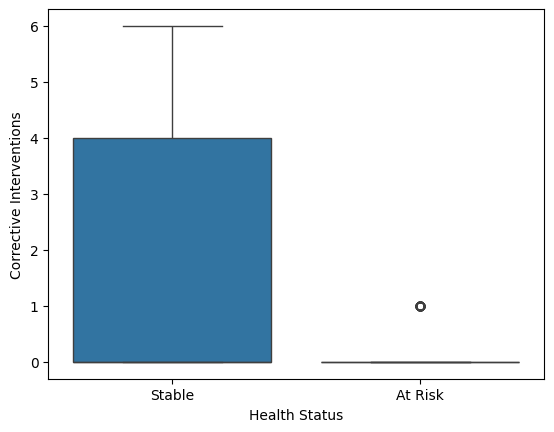

In [9]:
sns.boxplot(x='Health Status', y='Corrective Interventions', data=data)
plt.show()

### Variable objetivo: Health Status

### Análisis preliminar variable por variable:

- Low Oxigen Alert: Constante, se puede eliminar
- Low Temperature, Hight Temperature: Constante, se puede eliminar
- Month: Variable categórica, podemos eliminar. las columnas que tienen valor julio se tomará como si hubieran sido a principios de més tal que puedan considerarse como Junio, dado la baja representación de este mes.
- Average Fish Weight: No se encontró ningúna peculiaridad con esta variable.
- Survival Rate: No se encontró ninguna particularidad con esta variable.
- Desease occurrance: Solo toma dos valores, 1 y 2, dos está muy subrepresentado, por lo que se puede eliminar la columna
- Dissolved Oxygen: No se ve ninguna peculiaridad en estos datos
- pH: No se ve ninguna peculiaridad con esta variable
- Turbidity: De acuerdo con internet, el agua limpia toma valores de turbiedad de 0, tiene sentido que esté mayor a 0, pero que no sea muy alto.
- Oxigenation interventions: Categórica, se tratará como tal, como vemos, no hay ninguna correlación, por lo que se puede eliminar
- Corrective Interventions: No hay peculiaridades con la variable. Sin embargo, al tener tantos ceros, se propone verificar como esta afecta a la variable objetivo. Según se ve, cuando el agua suele estar en riesgo, no tiene mucho riesgo, por lo tanto, se propone conservarla
- Oxigenation automatic: Se deja la variable, no tiene particularidades
- Thermal risk index: Tiene una correlación al 100% con la variable objetivo y sirve para definirla, se va a eliminar
- Health Status: Altamente desbalanceada, se considerará hacer rebalanceo

# Separación de datos

In [10]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [11]:
# Asegurar que X_train sea un DataFrame
X_train = train.drop(columns=['Health Status'])
y_train = train['Health Status']


In [12]:
def fix_cat_values(df):
  for column in df.columns:
    if column == 'Month':
        df['Month'] = df['Month'].replace('July', 'June')
  return df

num_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# cat_transformer aplica de primer paso nuestra funcion complementaria y luego sobre ese resultado aplica OneHotEncoder
cat_transformer = Pipeline(
    steps=[
        ('fix-vals', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [13]:
cat = ['Month', 'Oxygenation Automatic']
num = ['Average Fish Weight (g)', 'Survival Rate (%)', 'Temperature (°C)', 
    'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)', 'Corrective Interventions']

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num),
        ("cat", cat_transformer, cat),
    ],
    remainder='drop'
)

In [15]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(random_state=42, kernel='rbf'))
], verbose=True)

In [16]:
param_grid = {
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()],
    'preprocessor__cat__encoder': [OneHotEncoder(handle_unknown='ignore'), OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['rbf']
}

In [17]:
# GridSearch con verbose para ver qué está fallando
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=2, error_score='raise')
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] ............... (step 3 of 3) Processing svm, total=   0.0s
[CV] END preprocessor__cat__encoder=OneHotEncoder(handle_unknown='ignore'), preprocessor__num__scaler=StandardScaler(), svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] ............... (step 3 of 3) Processing svm, total=   0.0s
[CV] END preprocessor__cat__encoder=OneHotEncoder(handle_unknown='ignore'), preprocessor__num__scaler=StandardScaler(), svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s

GridSearchCV(cv=3, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Average '
                                                                          'Fish '
                                                                          'Weight '
                                                                          '(g)',
                                                                          'Survival '
                                                                          'Rate '
                                                                          '(%)',
                                                                          'Temperature '
                                                                          '(°C)',
                                                                          'Dissolved '
                                                                          'Oxygen '
                                                                          '(mg/L)',
                                                                          'pH',
                                                                          'Turbidity '
                                                                          '(NTU)',
                                                                          'Corrective '
                                                                          'Interventions']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('fix-va...
                                       ('svm', SVC(random_state=42))],
                                verbose=True),
             param_grid={'preprocessor__cat__encoder': [OneHotEncoder(handle_unknown='ignore'),
                                                        OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                       unknown_value=-1)],
                         'preprocessor__num__scaler': [StandardScaler(),
                                                       MinMaxScaler()],
                         'svm__C': [0.1, 1, 10],
                         'svm__gamma': ['scale', 'auto'],
                         'svm__kernel': ['rbf']},
             scoring='accuracy', verbose=2)

In [18]:
best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)
print("Exactitud en entrenamiento:", grid_search.best_score_)

Mejores parámetros: {'preprocessor__cat__encoder': OneHotEncoder(handle_unknown='ignore'), 'preprocessor__num__scaler': StandardScaler(), 'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Exactitud en entrenamiento: 1.0


In [19]:
a = test.iloc[1:2]
X_a = a.drop('Health Status', axis=1)
y_a = a['Health Status']

y_pred = best_model.predict(X_a)

In [20]:
a = test[test['Health Status'] == 'At Risk'][0:1]
X_a = a.drop('Health Status', axis=1)
y_a = a['Health Status']

y_pred = best_model.predict(X_a)

In [21]:
y_pred

array(['At Risk'], dtype=object)

# Árboles de decision

In [22]:
# cat_transformer aplica de primer paso nuestra funcion complementaria y luego sobre ese resultado aplica OneHotEncoder
cat_transformer_tree = Pipeline(
    steps=[
        ('fix-vals', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", 'passthrough', num),
        ("cat", cat_transformer_tree, cat),
    ],
    remainder='drop'
)

pipeline_tree = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('smote', SMOTE(random_state=42)), 
    ('tree', DecisionTreeClassifier(random_state=42))
], verbose=True)

In [23]:
param_grid = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [10, 20, 30],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__max_features': [None, 'sqrt', 'log2']
}

# GridSearch con verbose para ver qué está fallando
grid_search_tree = GridSearchCV(pipeline_tree, param_grid, cv=3, scoring='accuracy', verbose=2, error_score='raise')
grid_search_tree.fit(X_train, y_train)

Fitting 3 folds for each of 162 candidates, totalling 486 fits
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=10, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=10, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[C

GridSearchCV(cv=3, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['Average '
                                                                          'Fish '
                                                                          'Weight '
                                                                          '(g)',
                                                                          'Survival '
                                                                          'Rate '
                                                                          '(%)',
                                                                          'Temperature '
                                                                          '(°C)',
                                                                          'Dissolved '
                                                                          'Oxygen '
                                                                          '(mg/L)',
                                                                          'pH',
                                                                          'Turbidity '
                                                                          '(NTU)',
                                                                          'Corrective '
                                                                          'Interventions']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('fix-vals',
                                                                                          FunctionTransformer(func=<fu...
                                                                         ['Month',
                                                                          'Oxygenation '
                                                                          'Automatic'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('tree',
                                        DecisionTreeClassifier(random_state=42))],
                                verbose=True),
             param_grid={'tree__criterion': ['gini', 'entropy'],
                         'tree__max_depth': [10, 20, 30],
                         'tree__max_features': [None, 'sqrt', 'log2'],
                         'tree__min_samples_leaf': [1, 2, 4],
                         'tree__min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=2)

In [24]:
best_model_tree = grid_search_tree.best_estimator_
print("Mejores parámetros:", grid_search_tree.best_params_)
print("Exactitud en entrenamiento:", grid_search_tree.best_score_)

Mejores parámetros: {'tree__criterion': 'gini', 'tree__max_depth': 10, 'tree__max_features': None, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Exactitud en entrenamiento: 1.0


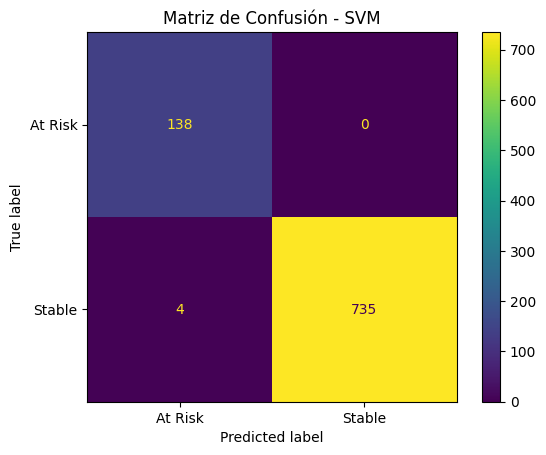

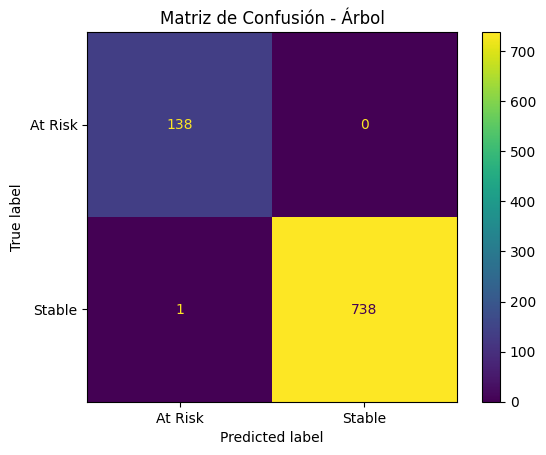

In [25]:
X_test = test.drop(columns=['Health Status'])
y_test = test['Health Status']

y_pred_svm = best_model.predict(X_test)

y_pred_tree = best_model_tree.predict(X_test)

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=best_model.named_steps['svm'].classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=best_model.named_steps['svm'].classes_)
disp_svm.plot()
plt.title("Matriz de Confusión - SVM")
plt.show()

cm_tree = confusion_matrix(y_test, y_pred_tree, labels=best_model_tree.named_steps['tree'].classes_)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=best_model_tree.named_steps['tree'].classes_)
disp_tree.plot()
plt.title("Matriz de Confusión - Árbol")
plt.show()

In [26]:
# Reporte para el modelo SVM
print("Reporte de métricas para el modelo SVM:")
print(classification_report(y_test, y_pred_svm))

# Reporte para el modelo Árbol de Decisión
print("Reporte de métricas para el modelo Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

Reporte de métricas para el modelo SVM:
              precision    recall  f1-score   support

     At Risk       0.97      1.00      0.99       138
      Stable       1.00      0.99      1.00       739

    accuracy                           1.00       877
   macro avg       0.99      1.00      0.99       877
weighted avg       1.00      1.00      1.00       877

Reporte de métricas para el modelo Árbol de Decisión:
              precision    recall  f1-score   support

     At Risk       0.99      1.00      1.00       138
      Stable       1.00      1.00      1.00       739

    accuracy                           1.00       877
   macro avg       1.00      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



In [27]:
pipeline_tree_2 = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('smote', SMOTE(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42, max_depth=3))
], verbose=True)

param_grid_tree_2 = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__max_features': [None, 'sqrt', 'log2']
}

grid_search_tree_2 = GridSearchCV(pipeline_tree_2, param_grid_tree_2, cv=3, scoring='accuracy', verbose=2, error_score='raise')
grid_search_tree_2.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_fe

GridSearchCV(cv=3, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['Average '
                                                                          'Fish '
                                                                          'Weight '
                                                                          '(g)',
                                                                          'Survival '
                                                                          'Rate '
                                                                          '(%)',
                                                                          'Temperature '
                                                                          '(°C)',
                                                                          'Dissolved '
                                                                          'Oxygen '
                                                                          '(mg/L)',
                                                                          'pH',
                                                                          'Turbidity '
                                                                          '(NTU)',
                                                                          'Corrective '
                                                                          'Interventions']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('fix-vals',
                                                                                          FunctionTransformer(func=<fu...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Month',
                                                                          'Oxygenation '
                                                                          'Automatic'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('tree',
                                        DecisionTreeClassifier(max_depth=3,
                                                               random_state=42))],
                                verbose=True),
             param_grid={'tree__criterion': ['gini', 'entropy'],
                         'tree__max_features': [None, 'sqrt', 'log2'],
                         'tree__min_samples_leaf': [1, 2, 4],
                         'tree__min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=2)

In [28]:
best_model_tree_2 = grid_search_tree_2.best_estimator_
print("Mejores parámetros:", grid_search_tree_2.best_params_)
print("Exactitud en entrenamiento:", grid_search_tree_2.best_score_)

Mejores parámetros: {'tree__criterion': 'gini', 'tree__max_features': None, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Exactitud en entrenamiento: 1.0


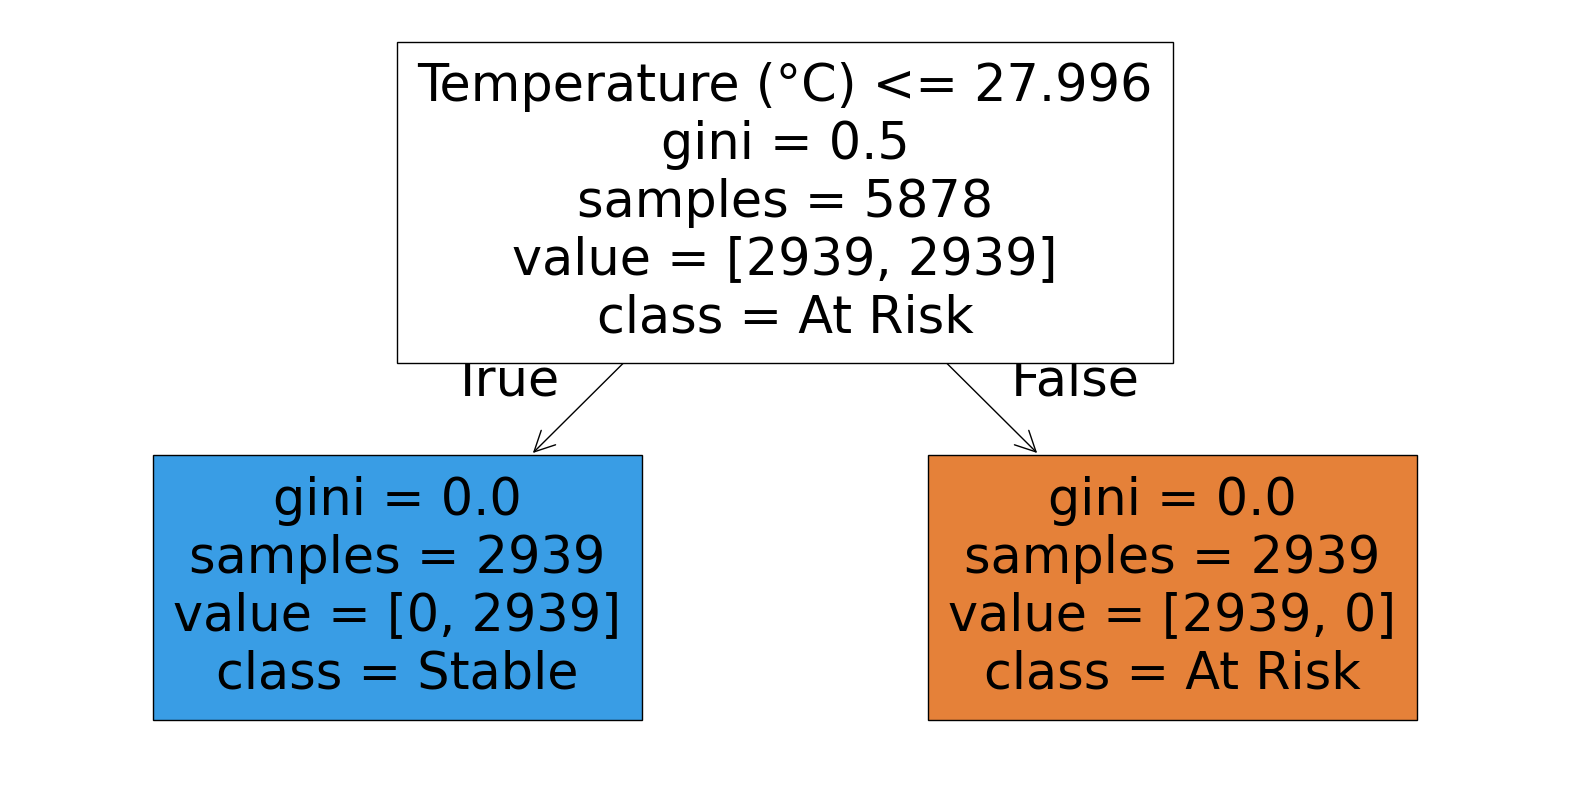

In [29]:
best_model_tree_2 = grid_search_tree_2.best_estimator_
tree_model = best_model_tree_2.named_steps['tree']

cat_column_names = best_model_tree_2[0].transformers_[1][1][1].get_feature_names_out()
num_column_names = best_model_tree_2[0].transformers_[0][1].feature_names_in_

col_names = list(num_column_names) + list(cat_column_names)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=col_names, 
          class_names=[str(cls) for cls in tree_model.classes_], 
          filled=True)
plt.show()


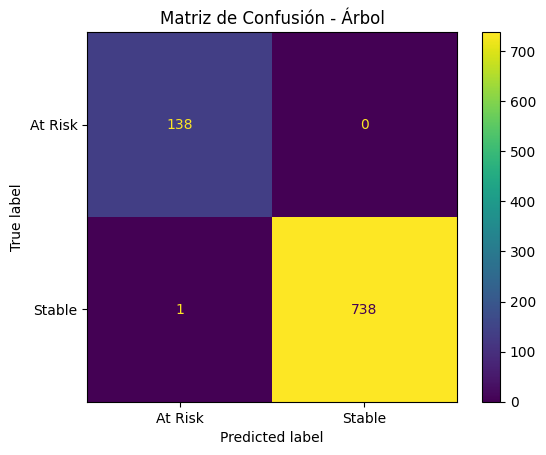

In [30]:
y_pred_tree = best_model_tree_2.predict(X_test)

cm_tree = confusion_matrix(y_test, y_pred_tree, labels=best_model_tree.named_steps['tree'].classes_)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=best_model_tree.named_steps['tree'].classes_)
disp_tree.plot()
plt.title("Matriz de Confusión - Árbol")
plt.show()